Import required libraries

In [3]:
import numpy as np
import time
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import KFold

Data loading and standardization

In [4]:
X_raw = np.loadtxt("dataF_final.csv", delimiter=",")
Y_raw = np.loadtxt("dataC_final.csv", delimiter=",")

if Y_raw.ndim == 1:
    Y_raw = Y_raw.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(X_raw)
Y = scaler_y.fit_transform(Y_raw)


Cross-validated RMSE for subset evaluation

In [5]:
def cv_rmse(X, y, n_comp=None):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []

    if n_comp is not None:
        model = PLSRegression(n_components=min(n_comp, X.shape[1]))
    else:
        model = LinearRegression()

    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))

    return np.mean(rmses)

Stepwise Feature Selection (Forward–Backward)

The algorithm iteratively searches for the subset of wavelengths (features) that minimizes prediction error.

In [ ]:
def stepwise_selection(X, y, max_features=50):

    n_features = X.shape[1]
    remaining = list(range(n_features))
    selected = []

    best_global_rmse = float('inf')
    improved = True

    while improved and len(selected) < max_features:
        improved = False

        forward_scores = []
        for f in remaining:
            subset = selected + [f]
            rmse = cv_rmse(X[:, subset], y, n_comp=min(10, len(subset)))
            forward_scores.append((rmse, f))

        forward_scores.sort()
        best_forward_rmse, best_feature = forward_scores[0]

        if best_forward_rmse < best_global_rmse:
            selected.append(best_feature)
            remaining.remove(best_feature)
            best_global_rmse = best_forward_rmse
            improved = True

            
        while len(selected) > 2:
            backward_scores = []

            for f in selected:
                subset = [x for x in selected if x != f]
                rmse = cv_rmse(X[:, subset], y, n_comp=min(10, len(subset)))
                backward_scores.append((rmse, f))

            backward_scores.sort()
            best_backward_rmse, worst_feature = backward_scores[0]

            if best_backward_rmse < best_global_rmse:
                selected.remove(worst_feature)
                remaining.append(worst_feature)
                best_global_rmse = best_backward_rmse
                improved = True
            else:
                break

    return np.array(selected)


Regression models

In [9]:
results_list = []
all_predictions = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_models = {
    "PLSR": PLSRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.001, max_iter=20000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000)
}

Stepwise and Model evaluation

In [10]:
print(f"{'Target':<8} | {'Model':<12} | {'R2_test':<10} | {'RMSE_test':<10} | {'Features':<8}")
print("-" * 75)

for t in range(Y.shape[1]):
    print(f"\nOptimizing Target {t+1}")
    start = time.time()

    y_target = Y[:, t]

    best_features = stepwise_selection(X, y_target, max_features=50)
    X_selected = X[:, best_features]

    fold_scores = {name: {"r2": [], "rmse": []} for name in test_models.keys()}

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected)):

        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_target[train_idx], y_target[test_idx]

        for name, model in test_models.items():

            if name == "PLSR":
                model = PLSRegression(n_components=min(20, X_train.shape[1]))

            model.fit(X_train, y_train)
            pred = model.predict(X_test).flatten()

            key = (t+1, name)
            if key not in all_predictions:
                all_predictions[key] = [[], []]

            all_predictions[key][0].extend(y_test)
            all_predictions[key][1].extend(pred)

            fold_scores[name]["r2"].append(r2_score(y_test, pred))
            fold_scores[name]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))

    for name in test_models.keys():
        results_list.append({
            "Target": t+1,
            "Model": name,
            "R2_test": np.mean(fold_scores[name]["r2"]),
            "RMSE_test": np.mean(fold_scores[name]["rmse"]),
            "Features": len(best_features),
            "Runtime_sec": time.time() - start
        })

        print(f"T{t+1:<6} | {name:<12} | {np.mean(fold_scores[name]['r2']):.4f}   | {np.mean(fold_scores[name]['rmse']):.4f}   | {len(best_features):<8}")

    print(f"Time: {time.time() - start:.2f}s")

Target   | Model        | R2_test    | RMSE_test  | Features
---------------------------------------------------------------------------

Optimizing Target 1
T1      | PLSR         | 0.7485   | 0.4954   | 50      
T1      | Ridge        | 0.7523   | 0.4919   | 50      
T1      | Lasso        | 0.7477   | 0.4963   | 50      
T1      | ElasticNet   | 0.7485   | 0.4955   | 50      
Time: 873.59s

Optimizing Target 2
T2      | PLSR         | 0.7346   | 0.5033   | 50      
T2      | Ridge        | 0.7358   | 0.5025   | 50      
T2      | Lasso        | 0.7325   | 0.5057   | 50      
T2      | ElasticNet   | 0.7332   | 0.5048   | 50      
Time: 684.61s

Optimizing Target 3
T3      | PLSR         | 0.7150   | 0.5102   | 50      
T3      | Ridge        | 0.7218   | 0.5046   | 50      
T3      | Lasso        | 0.7155   | 0.5100   | 50      
T3      | ElasticNet   | 0.7153   | 0.5100   | 50      
Time: 663.79s

Optimizing Target 4
T4      | PLSR         | 0.7619   | 0.4770   | 50      
T4      |

Best Model Per Target (Stepwise)

In [11]:
results_df_stepwise = pd.DataFrame(results_list)
best_models_stepwise = (
    results_df_stepwise.sort_values("RMSE_test")
    .groupby("Target")
    .first()
    .reset_index()
)

best_models_stepwise

,Target,Model,R2_test,RMSE_test,Features,Runtime_sec
0,1,Ridge,0.752279,0.491851,50,873.593997
1,2,Ridge,0.735849,0.502532,50,684.612446
2,3,Ridge,0.721785,0.504611,50,663.791489
3,4,Ridge,0.766393,0.473571,50,665.505086
4,5,Ridge,0.575625,0.621965,50,740.062093


Predicted vs Observed for best model per target

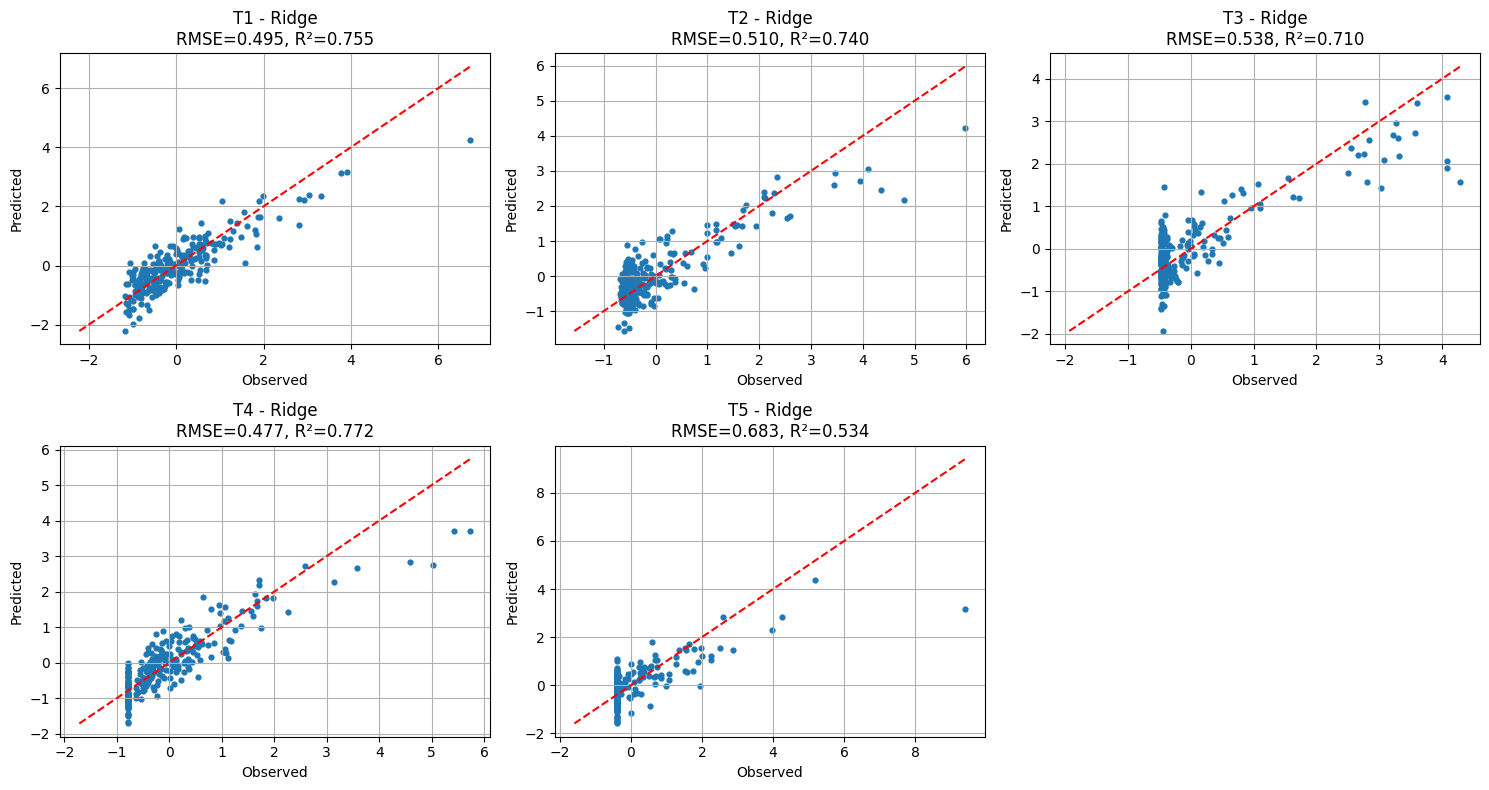

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def plot_best_models(best_models, all_predictions):

    cols = 3
    rows = int(np.ceil(len(best_models) / cols))
    plt.figure(figsize=(15, 4 * rows))

    for i, row in best_models.iterrows():
        t = row["Target"]
        model = row["Model"]

        y_true = np.array(all_predictions[(t, model)][0])
        y_pred = np.array(all_predictions[(t, model)][1])

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        plt.subplot(rows, cols, i + 1)
        plt.scatter(y_true, y_pred, s=12)

        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        plt.plot([min_v, max_v], [min_v, max_v], "r--")

        plt.title(f"T{t} - {model}\nRMSE={rmse:.3f}, R²={r2:.3f}")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.grid()

    plt.tight_layout()
    plt.show()
plot_best_models(best_models_stepwise, all_predictions)